# R1 Rejector: Best Validation Accuracy

Boxplot der besten Validierungsgenauigkeit pro Run fuer die vier Rejector-Architekturen im `embedding`-Ordner.

In [8]:
from pathlib import Path
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
})

In [9]:
RUN_ROOT = Path(
    "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/"
    "tensorboard_runs/tensorboard_runs_rejector-new-targets/embedding"
).resolve()

PLOTS_DIR = Path("/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot").resolve()
OUT_DIR = PLOTS_DIR / "figures_r1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ARCHITECTURES = {
    "conv-mlp": "conv_mlp",
    "conv-gap": "conv_gap",
    "spatial-mlp": "spatial_pool_mlp",
    "pooled-mlp": "pooled_mlp",
}

RUN_ROOT, OUT_DIR

(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs/tensorboard_runs_rejector-new-targets/embedding'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot/figures_r1'))

In [10]:
def read_accuracy_val(run_dir: Path) -> list[dict]:
    scalar_dir = run_dir / "Accuracy_val"
    event_files = sorted(scalar_dir.glob("events.out.tfevents.*"))
    if not event_files:
        return []

    accumulator = EventAccumulator(str(scalar_dir), size_guidance={"scalars": 0})
    accumulator.Reload()
    tags = accumulator.Tags().get("scalars", [])
    if not tags:
        return []

    tag = "Accuracy_val" if "Accuracy_val" in tags else tags[0]
    return [
        {"epoch": event.step, "wall_time": event.wall_time, "value": float(event.value), "tb_tag": tag}
        for event in accumulator.Scalars(tag)
    ]


def load_best_validation_accuracies(run_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    best_rows = []
    run_rows = []

    for architecture, dirname in ARCHITECTURES.items():
        architecture_dir = run_root / dirname
        run_dirs = sorted(p for p in architecture_dir.iterdir() if p.is_dir() and p.name.startswith("run_"))

        for run_dir in run_dirs:
            meta = {
                "architecture": architecture,
                "architecture_dir": dirname,
                "run": run_dir.name,
                "run_path": str(run_dir),
            }

            try:
                events = read_accuracy_val(run_dir)
            except Exception as exc:
                warnings.warn(f"Konnte {run_dir / 'Accuracy_val'} nicht lesen: {exc}")
                events = []

            run_rows.append({
                **meta,
                "n_val_points": len(events),
                "status": "ok" if events else "kein Accuracy_val",
            })

            if not events:
                continue

            best_event = max(events, key=lambda event: event["value"])
            best_rows.append({
                **meta,
                "best_val_accuracy": best_event["value"],
                "best_epoch": best_event["epoch"],
                "n_val_points": len(events),
            })

    best = pd.DataFrame(best_rows)
    runs = pd.DataFrame(run_rows)
    return best, runs

In [11]:
best_val, runs = load_best_validation_accuracies(RUN_ROOT)

summary = (
    runs.groupby("architecture", sort=False)
    .agg(
        runs=("run", "size"),
        runs_with_accuracy_val=("n_val_points", lambda values: int((values > 0).sum())),
    )
    .reindex(ARCHITECTURES.keys())
)

print(f"Geladen: {len(best_val)} Runs mit Accuracy_val aus {len(runs)} Run-Verzeichnissen")
display(summary)
display(best_val.sort_values(["architecture", "best_val_accuracy"], ascending=[True, False]).head(10))

Geladen: 183 Runs mit Accuracy_val aus 244 Run-Verzeichnissen


,runs,runs_with_accuracy_val
architecture,,
conv-mlp,61,40
conv-gap,60,44
spatial-mlp,64,40
pooled-mlp,59,59


,architecture,architecture_dir,run,run_path,best_val_accuracy,best_epoch,n_val_points
74,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr5.99e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.583201,52,67
80,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr8.96e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.582776,32,47
78,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr6.93e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.581804,37,52
82,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr9.34e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.581580,38,53
65,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr4.58e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.581323,68,83
60,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr3.41e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.580429,57,72
58,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr2.70e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.579557,90,100
54,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr1.77e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.578943,90,100
59,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr3.12e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.577780,86,100
57,conv-gap,conv_gap,run_embedding_3_GAP_conv_gap_lr2.52e-05_wd0.00...,/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_c...,0.576506,94,100


(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot/figures_r1/r1_rejector_best_val_accuracy_boxplot.png'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot/figures_r1/r1_rejector_best_val_accuracy_boxplot.pdf'))

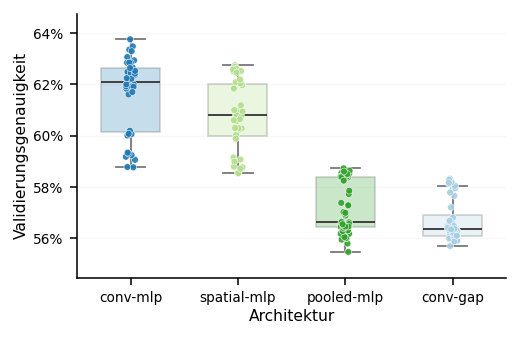

In [ ]:
PALETTE = {
    "conv-mlp": "#1f78b4",
    "conv-gap": "#a6cee3",
    "spatial-mlp": "#b2df8a",
    "pooled-mlp": "#33a02c",
}

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,
})

labels = [
    "conv-mlp",
    "spatial-mlp",
    "pooled-mlp",
    "conv-gap",
]
plot_data = best_val.dropna(subset=["best_val_accuracy"])

fig, ax = plt.subplots(figsize=(3.6, 2.3), constrained_layout=True)
sns.boxplot(
    data=plot_data,
    x="architecture",
    y="best_val_accuracy",
    hue="architecture",
    order=labels,
    hue_order=labels,
    palette=PALETTE,
    width=0.55,
    showfliers=False,
    saturation=1,
    legend=False,
    medianprops={"color": "0.25", "linewidth": 1.0},
    whiskerprops={"color": "0.45", "linewidth": 0.9},
    capprops={"color": "0.45", "linewidth": 0.9},
    ax=ax,
)

for patch, label in zip(ax.patches, labels):
    patch.set_facecolor(PALETTE[label])
    patch.set_alpha(0.25)
    patch.set_edgecolor("0.35")
    patch.set_linewidth(0.9)

np.random.seed(42)
sns.stripplot(
    data=plot_data,
    x="architecture",
    y="best_val_accuracy",
    hue="architecture",
    order=labels,
    hue_order=labels,
    palette=PALETTE,
    jitter=0.045,
    size=3.5,
    legend=False,
    edgecolor="white",
    linewidth=0.3,
    alpha=0.9,
    zorder=3,
    ax=ax,
)

ax.set_xlabel("Architektur", labelpad=4)
ax.set_ylabel("Validierungsgenauigkeit", labelpad=4)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))
ax.grid(axis="y", color="0.90", linewidth=0.7, linestyle="-")
ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", rotation=0)
sns.despine(ax=ax)

y_values = best_val["best_val_accuracy"].dropna()
if not y_values.empty:
    ypad = max((float(y_values.max()) - float(y_values.min())) * 0.08, 0.01)
    ax.set_ylim(max(0.0, float(y_values.min()) - ypad), min(1.0, float(y_values.max()) + ypad))

png_path = OUT_DIR / "r1_rejector_best_val_accuracy_boxplot.png"
pdf_path = OUT_DIR / "r1_rejector_best_val_accuracy_boxplot.pdf"
fig.savefig(png_path)
fig.savefig(pdf_path)

png_path, pdf_path